# ML lab11-1: TensorFlow CNN Basics

In [ ]:
import numpy as np
import tensorflow as tf
import random
import matplotlib.pyplot as plt

(1, 3, 3, 1)


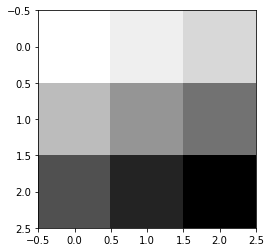

In [ ]:
# 이미지 생성
image = np.array([1,2,3,4,5,6,7,8,9], dtype=np.float32)
image = image.reshape([1,3,3,1])
print(image.shape)
plt.imshow(image.reshape(3,3), cmap='Greys')
plt.show()

In [ ]:
# filter 생성
weight = np.array([1,1,1,1], dtype=np.float32)
weight = filter.reshape(2,2,1,1)

In [ ]:
conv2d = tf.nn.conv2d(image, weight, strides=[1,1,1,1], padding='VALID')
conv2d

<tf.Tensor: shape=(1, 2, 2, 1), dtype=float32, numpy=
array([[[[12.],
         [16.]],

        [[24.],
         [28.]]]], dtype=float32)>

## padding

`padding='SAME'`으로 설정하면 필터를 거친 값이 원본의 크기와 동일해진다.

In [ ]:
conv2d = tf.nn.conv2d(image, weight, strides=[1,1,1,1], padding='SAME')
conv2d

<tf.Tensor: shape=(1, 3, 3, 1), dtype=float32, numpy=
array([[[[12.],
         [16.],
         [ 9.]],

        [[24.],
         [28.],
         [15.]],

        [[15.],
         [17.],
         [ 9.]]]], dtype=float32)>

## pooling

In [ ]:
# 이미지 생성
image = np.array([4,3,2,1], dtype=np.float32)
image = image.reshape([1,2,2,1])

In [ ]:
pool = tf.nn.max_pool(image, ksize=[1,2,2,1],strides=[1,1,1,1],padding='SAME')
pool

<tf.Tensor: shape=(1, 2, 2, 1), dtype=float32, numpy=
array([[[[4.],
         [3.]],

        [[2.],
         [1.]]]], dtype=float32)>

## Mnist 사용하기

In [ ]:
import numpy as np
import tensorflow as tf
import random
import matplotlib.pyplot as plt
from tensorflow import keras

(train_input, train_target), (test_input, test_target) = keras.datasets.mnist.load_data()

11501568/11490434 [==============================] - 0s 0us/step


In [ ]:
img = train_input.reshape(-1,28,28,1)
img.shape

(60000, 28, 28, 1)

In [ ]:
W1 = tf.Variable(tf.random.normal([3,3,1,5]))
conv2d = tf.nn.conv2d(img, W1, strides=[1,2,2,1], padding='SAME')

In [ ]:
pool = tf.nn.max_pool(conv2d, ksize=[1,2,2,1], strides=[1,2,2,1], padding='SAME')
pool.shape

TensorShape([60000, 7, 7, 5])

# ML lab11-2: MNIST 99% with CNN

In [ ]:
import numpy as np
import tensorflow as tf
import random
import matplotlib.pyplot as plt
from tensorflow import keras

(train_input, train_target), (test_input, test_target) = keras.datasets.mnist.load_data()
train_input, test_input = train_input / 255.0, test_input / 255.0
train_input, test_input = train_input.reshape(-1,28,28,1), test_input.reshape(-1,28,28,1)

# hyper parameters
learning_rate = 0.001
training_epochs = 12
batch_size = 128

In [ ]:
model = keras.models.Sequential([
    # conv layer 1                                 
    keras.layers.Conv2D(filters=32, kernel_size=(3, 3), input_shape=(28, 28, 1), padding='same', activation='relu'),
    keras.layers.MaxPool2D(pool_size=(2, 2), padding='same'),
    # conv layer 2
    keras.layers.Conv2D(filters=64, kernel_size=(3, 3), padding='same', activation='relu'),
    keras.layers.MaxPool2D(pool_size=(2, 2), padding='same'),
    # FL
    keras.layers.Flatten(),
    keras.layers.Dense(10, kernel_initializer='glorot_normal', activation='softmax')
])
model.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_13 (Conv2D)          (None, 28, 28, 32)        320       
                                                                 
 max_pooling2d_13 (MaxPoolin  (None, 14, 14, 32)       0         
 g2D)                                                            
                                                                 
 conv2d_14 (Conv2D)          (None, 14, 14, 64)        18496     
                                                                 
 max_pooling2d_14 (MaxPoolin  (None, 7, 7, 64)         0         
 g2D)                                                            
                                                                 
 flatten_5 (Flatten)         (None, 3136)              0         
                                                                 
 dense_8 (Dense)             (None, 10)               

In [ ]:
model.compile(loss='sparse_categorical_crossentropy', 
              optimizer= keras.optimizers.Adam(learning_rate=learning_rate),
              metrics=['accuracy'])

In [ ]:
model.fit(train_input, train_target, batch_size=batch_size, epochs=training_epochs)

Epoch 1/12
469/469 [==============================] - 2s 4ms/step - loss: 0.2627 - accuracy: 0.9231
Epoch 2/12
469/469 [==============================] - 2s 4ms/step - loss: 0.0659 - accuracy: 0.9802
Epoch 3/12
469/469 [==============================] - 2s 4ms/step - loss: 0.0495 - accuracy: 0.9851
Epoch 4/12
469/469 [==============================] - 2s 4ms/step - loss: 0.0389 - accuracy: 0.9885
Epoch 5/12
469/469 [==============================] - 2s 4ms/step - loss: 0.0333 - accuracy: 0.9896
Epoch 6/12
469/469 [==============================] - 2s 4ms/step - loss: 0.0275 - accuracy: 0.9915
Epoch 7/12
469/469 [==============================] - 3s 5ms/step - loss: 0.0246 - accuracy: 0.9924
Epoch 8/12
469/469 [==============================] - 3s 6ms/step - loss: 0.0200 - accuracy: 0.9938
Epoch 9/12
469/469 [==============================] - 2s 5ms/step - loss: 0.0177 - accuracy: 0.9943
Epoch 10/12
469/469 [==============================] - 2s 4ms/step - loss: 0.0151 - accuracy: 0.9952

In [ ]:
model.evaluate(test_input, test_target)

313/313 [==============================] - 1s 3ms/step - loss: 0.0331 - accuracy: 0.9900


[0.033140797168016434, 0.9900000095367432]

# 조금 더 깊게 만들어보기

In [ ]:
import numpy as np
import tensorflow as tf
import random
import matplotlib.pyplot as plt
from tensorflow import keras

(train_input, train_target), (test_input, test_target) = keras.datasets.mnist.load_data()
train_input /= 255.0
test_input /= 255.0
train_input, test_input = train_input.reshape(-1,28,28,1), test_input.reshape(-1,28,28,1)

# hyper parameters
learning_rate = 0.001
training_epochs = 12
batch_size = 128

In [ ]:
model = keras.models.Sequential([
    # conv layer 1                                 
    keras.layers.Conv2D(filters=32, kernel_size=(3, 3), input_shape=(28, 28, 1), padding='same', activation='relu'),
    keras.layers.MaxPool2D(pool_size=(2, 2), padding='same'),
    # conv layer 2
    keras.layers.Conv2D(filters=64, kernel_size=(3, 3), padding='same', activation='relu'),
    keras.layers.MaxPool2D(pool_size=(2, 2), padding='same'),
    # conv layer 3
    keras.layers.Conv2D(filters=128, kernel_size=(3, 3), padding='same', activation='relu'),
    keras.layers.MaxPool2D(pool_size=(2, 2), padding='same'),
    # FL
    keras.layers.Flatten(),
    keras.layers.Dense(625, kernel_initializer='glorot_normal', activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(10, kernel_initializer='glorot_normal', activation='softmax')
])
model.summary()

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_15 (Conv2D)          (None, 28, 28, 32)        320       
                                                                 
 max_pooling2d_15 (MaxPoolin  (None, 14, 14, 32)       0         
 g2D)                                                            
                                                                 
 conv2d_16 (Conv2D)          (None, 14, 14, 64)        18496     
                                                                 
 max_pooling2d_16 (MaxPoolin  (None, 7, 7, 64)         0         
 g2D)                                                            
                                                                 
 conv2d_17 (Conv2D)          (None, 7, 7, 128)         73856     
                                                                 
 max_pooling2d_17 (MaxPoolin  (None, 4, 4, 128)       

In [ ]:
model.compile(loss='sparse_categorical_crossentropy', 
              optimizer= keras.optimizers.Adam(learning_rate=learning_rate),
              metrics=['accuracy'])

early_stopping_cb = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)    # 조기종료 설정
model.fit(train_input, train_target, batch_size=batch_size, 
          epochs=training_epochs, validation_data=(test_input, test_target), 
          callbacks=[early_stopping_cb])

Epoch 1/12
469/469 [==============================] - 3s 6ms/step - loss: 0.1786 - accuracy: 0.9424 - val_loss: 0.0535 - val_accuracy: 0.9838
Epoch 2/12
469/469 [==============================] - 3s 6ms/step - loss: 0.0476 - accuracy: 0.9847 - val_loss: 0.0320 - val_accuracy: 0.9893
Epoch 3/12
469/469 [==============================] - 3s 5ms/step - loss: 0.0336 - accuracy: 0.9891 - val_loss: 0.0229 - val_accuracy: 0.9920
Epoch 4/12
469/469 [==============================] - 3s 6ms/step - loss: 0.0239 - accuracy: 0.9925 - val_loss: 0.0222 - val_accuracy: 0.9930
Epoch 5/12
469/469 [==============================] - 3s 6ms/step - loss: 0.0212 - accuracy: 0.9930 - val_loss: 0.0272 - val_accuracy: 0.9902
Epoch 6/12
469/469 [==============================] - 3s 6ms/step - loss: 0.0157 - accuracy: 0.9950 - val_loss: 0.0208 - val_accuracy: 0.9929
Epoch 7/12
469/469 [==============================] - 3s 7ms/step - loss: 0.0140 - accuracy: 0.9955 - val_loss: 0.0252 - val_accuracy: 0.9928
Epoch 

# 이것저것 해보기

## - 10개의 필터 사용해서 이미지 보기

In [ ]:
import numpy as np
import tensorflow as tf
import random
import matplotlib.pyplot as plt
from tensorflow import keras

image = np.array([1,2,3,4,5,6,7,8,9], dtype=np.float32)
image = image.reshape([1,3,3,1])

In [ ]:
conv2d = keras.layers.Conv2D(filters=10, kernel_size=(2,2), padding='SAME')(image)

In [ ]:
feature_maps = np.swapaxes(conv2d, 0, 3)

In [ ]:
feature_maps.shape

(10, 3, 3, 1)

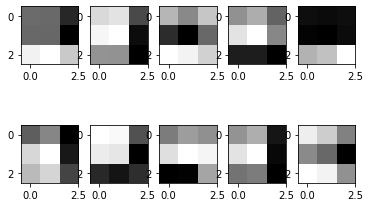

In [ ]:
for i,map in enumerate(feature_maps):
    plt.subplot(2,5,i+1), plt.imshow(map.reshape(3,3), cmap='gray')

## mnist 사용

In [ ]:
(train_input, train_target), (test_input, test_target) = keras.datasets.fashion_mnist.load_data()

4431872/4422102 [==============================] - 0s 0us/step


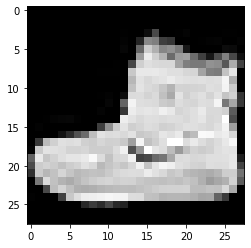

In [ ]:
plt.imshow(train_input[0], cmap='gray')

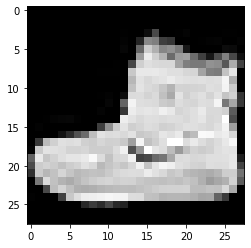

In [ ]:
img = (train_input[0] / 255.0).reshape(1,28,28,1)

conv

In [ ]:
conv2d = keras.layers.Conv2D(filters=5, kernel_size=(3,3), strides=(2,2), padding='SAME', activation='relu')(img)
print(conv2d.shape)
feature_maps = np.swapaxes(conv2d, 0, 3)

(1, 14, 14, 5)


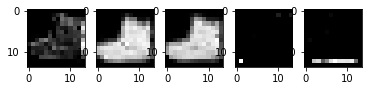

In [ ]:
for i,map in enumerate(feature_maps):
    plt.subplot(1,5,i+1), plt.imshow(map.reshape(14,14), cmap='gray')

maxpooling

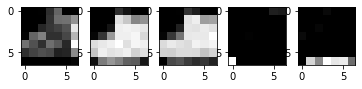

In [ ]:
pool = keras.layers.MaxPool2D(pool_size=(2,2), strides=(2,2), padding='SAME')(conv2d)
feature_maps = np.swapaxes(pool, 0, 3)
for i,map in enumerate(feature_maps):
    plt.subplot(1,5,i+1), plt.imshow(map.reshape(7,7), cmap='gray')